# iSDA soil bulk master (bronze) — reverse projection to WGS84

Load `isda_soil_bulk_master_bronze` from the local DB. The stored `latitude` / `longitude` values are in **EPSG:3857** (Web Mercator, meters). This notebook transforms them to **EPSG:4326** (WGS84) and adds `lat_wgs84` / `lon_wgs84`.

**Using Postgres (e.g. Docker)?** The first code cell loads `data/local/.env` so the notebook uses `LOCAL_DB_URL` and connects to the same Postgres as your DB explorer. Run from repo root.

## How to load data into the table

Data lives in **BigQuery**. To get rows into your local DB (PostgreSQL or SQLite), run one of these **from repo root** (with `data/local/.env` set: `BQ_PROJECT`, `BQ_DATASET`, `GOOGLE_APPLICATION_CREDENTIALS`; and `LOCAL_DB_URL` for Postgres, or leave unset for SQLite):

1. **Sync this table only** (recommended first time):
   ```bash
   python data/local/scripts/bq_partition_to_local.py --table isda_soil_bulk_master_bronze --target-table isda_soil_bulk_master_bronze --limit 50000
   ```
2. **Sync all bronze tables** (schema + data for every table in `bronze_tables.txt`):
   ```bash
   bash data/local/scripts/populate_local_db.sh
   ```

Then re-run this notebook; the table will have rows (if the table exists in your BigQuery dataset).

In [20]:
import os
import sys
from pathlib import Path

# Resolve repo root so we can import engine_connector (run from repo root or data-pipelines/bronze)
REPO_ROOT = None
for candidate in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    scripts_dir = candidate / "data" / "local" / "scripts"
    if (scripts_dir / "engine_connector.py").exists():
        if str(scripts_dir) not in sys.path:
            sys.path.insert(0, str(scripts_dir))
        REPO_ROOT = scripts_dir.parent.parent
        break

# Load data/local/.env so the notebook uses the same DB as your DB explorer (Postgres when LOCAL_DB_URL is set)
_env_file = (REPO_ROOT or Path.cwd()) / "data" / "local" / ".env"
if _env_file.exists():
    for line in _env_file.read_text().splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        if "=" in line:
            key, _, value = line.partition("=")
            key = key.strip().replace("export ", "", 1).strip()
            value = value.strip().strip("'\"")
            if key:
                os.environ[key] = value

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyproj
from engine_connector import get_engine
from sqlalchemy import text


In [21]:
# Load isda_soil_bulk_master_bronze from local DB (create table from schema if missing)
TABLE = "isda_soil_bulk_master_bronze"

# Ensure .env is loaded in this cell too (so Postgres is used even if cell 1 wasn't run)
for _c in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    _env = _c / "data" / "local" / ".env"
    if _env.exists():
        for _line in _env.read_text().splitlines():
            _line = _line.strip()
            if not _line or _line.startswith("#") or "=" not in _line:
                continue
            _k, _, _v = _line.partition("=")
            _k = _k.strip().replace("export ", "", 1).strip()
            _v = _v.strip().strip("'\"")
            if _k:
                os.environ[_k] = _v
        break

engine = get_engine()
try:
    from engine_connector import get_connection_url
    print("DB:", get_connection_url())
except Exception:
    print("DB:", "Postgres" if "postgresql" in str(engine.url) else str(engine.url))

# Find schema file by walking up from cwd (works even if REPO_ROOT wasn't set in cell 1)
schema_path = None
for candidate in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent, Path.cwd().parent.parent.parent]:
    p = candidate / "data" / "local" / "schema" / "bronze" / f"{TABLE}.sql"
    if p.exists():
        schema_path = p
        break

if schema_path is not None:
    ddl = schema_path.read_text()
    if "sqlite" in str(engine.url).lower():
        ddl = ddl.replace("TIMESTAMPTZ", "TEXT")
    with engine.begin() as conn:
        conn.execute(text(ddl))
else:
    # Fallback: inline DDL so table exists even when schema file not found (e.g. wrong cwd)
    is_sqlite = "sqlite" in str(engine.url).lower()
    ddl = f"""CREATE TABLE IF NOT EXISTS {TABLE} (
  latitude DOUBLE PRECISION,
  longitude DOUBLE PRECISION,
  value DOUBLE PRECISION,
  depth TEXT,
  property TEXT,
  ingested_at {"TEXT" if is_sqlite else "TIMESTAMPTZ"}
);"""
    with engine.begin() as conn:
        conn.execute(text(ddl))

with engine.connect() as conn:
    df = pd.read_sql(text(f"SELECT * FROM {TABLE}"), conn)

# Drop rows where projected coords are null so we can transform
df = df.dropna(subset=["latitude", "longitude"]).copy()
print(f"Loaded {len(df):,} rows. Columns: {list(df.columns)}")
if len(df) == 0:
    print("Table is empty. From repo root, run: python data/local/scripts/bq_partition_to_local.py --table isda_soil_bulk_master_bronze --target-table isda_soil_bulk_master_bronze")
df.head()

DB: postgresql:****@localhost:5432/datateam_local
Loaded 100,000 rows. Columns: ['latitude', 'longitude', 'value', 'depth', 'property', 'ingested_at']


,latitude,longitude,value,depth,property,ingested_at
0,4.287058e+06,550432.192357,26.0,0-20cm,stone_content,2026-01-31 13:20:22.015159+00:00
1,4.242058e+06,625432.192357,25.0,0-20cm,stone_content,2026-01-31 13:20:22.015159+00:00
2,4.194058e+06,919432.192357,24.0,0-20cm,stone_content,2026-01-31 13:20:22.015159+00:00
3,4.164058e+06,79432.192357,23.0,0-20cm,stone_content,2026-01-31 13:20:22.015159+00:00
4,4.083058e+06,-268567.807643,24.0,0-20cm,stone_content,2026-01-31 13:20:22.015159+00:00


In [22]:
# iSDA soil data is in Web Mercator (EPSG:3857). Reverse to WGS84 (EPSG:4326).
# Columns "latitude"/"longitude" in the table are stored as (y, x) in meters (3857).
SOURCE_CRS = "EPSG:3857"
TARGET_CRS = "EPSG:4326"
transformer = pyproj.Transformer.from_crs(SOURCE_CRS, TARGET_CRS, always_xy=True)

# Transform: input (x, y) = (longitude column, latitude column) in 3857
lon_wgs84, lat_wgs84 = transformer.transform(
    df["longitude"].values,
    df["latitude"].values,
)
df["lon_wgs84"] = lon_wgs84
df["lat_wgs84"] = lat_wgs84
df[["longitude", "latitude", "lon_wgs84", "lat_wgs84", "value", "depth", "property"]].head(10)

,longitude,latitude,lon_wgs84,lat_wgs84,value,depth,property
0,550432.192357,4.287058e+06,4.944617,35.901367,26.0,0-20cm,stone_content
1,625432.192357,4.242058e+06,5.618353,35.573244,25.0,0-20cm,stone_content
2,919432.192357,4.194058e+06,8.259400,35.221758,24.0,0-20cm,stone_content
3,79432.192357,4.164058e+06,0.713552,35.001302,23.0,0-20cm,stone_content
4,-268567.807643,4.083058e+06,-2.412586,34.403103,24.0,0-20cm,stone_content
5,-394567.807643,4.017058e+06,-3.544463,33.912494,27.0,0-20cm,stone_content
6,-442567.807643,3.945058e+06,-3.975654,33.374045,26.0,0-20cm,stone_content
7,-376567.807643,3.855058e+06,-3.382766,32.696271,27.0,0-20cm,stone_content
8,-568567.807643,3.819058e+06,-5.107532,32.423707,30.0,0-20cm,stone_content
9,-598567.807643,3.798058e+06,-5.377026,32.264329,27.0,0-20cm,stone_content


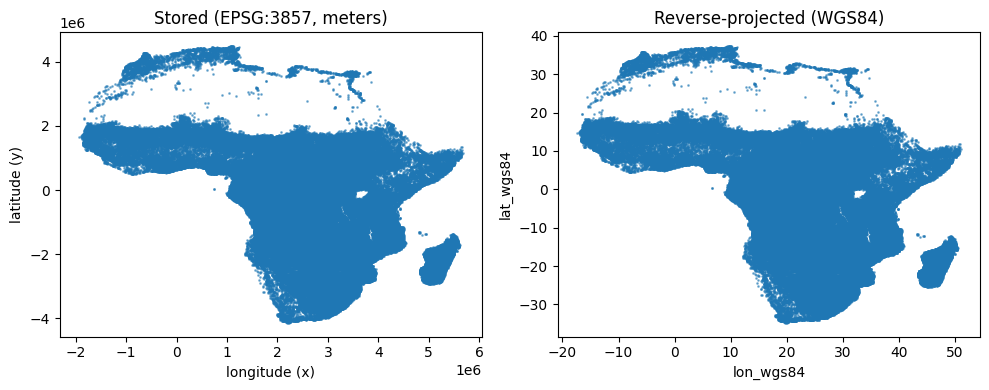

In [23]:
# Quick sanity check: WGS84 lat should be in [-90, 90], lon in [-180, 180]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(df["longitude"], df["latitude"], s=1, alpha=0.5)
axes[0].set_title("Stored (EPSG:3857, meters)")
axes[0].set_xlabel("longitude (x)"); axes[0].set_ylabel("latitude (y)")
axes[1].scatter(df["lon_wgs84"], df["lat_wgs84"], s=1, alpha=0.5)
axes[1].set_title("Reverse-projected (WGS84)")
axes[1].set_xlabel("lon_wgs84"); axes[1].set_ylabel("lat_wgs84")
plt.tight_layout()
plt.show()

In [24]:
df_reverse_geolocation = pd.read_csv("/Users/chidiokoene/projects/OpenTrace/data-team/data/ingestion/satellite/GIS/worldcitiespop.csv")

/var/folders/r1/1_5cpm6s4737b8bjgmfdc4000000gn/T/ipykernel_18741/1929733428.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_reverse_geolocation = pd.read_csv("/Users/chidiokoene/projects/OpenTrace/data-team/data/ingestion/satellite/GIS/worldcitiespop.csv")


In [25]:
df_reverse_geolocation

,Country,City,AccentCity,Region,Population,Latitude,Longitude
0,ad,aixas,Aixàs,6.0,NaN,42.483333,1.466667
1,ad,aixirivali,Aixirivali,6.0,NaN,42.466667,1.500000
2,ad,aixirivall,Aixirivall,6.0,NaN,42.466667,1.500000
3,ad,aixirvall,Aixirvall,6.0,NaN,42.466667,1.500000
4,ad,aixovall,Aixovall,6.0,NaN,42.466667,1.483333
...,...,...,...,...,...,...,...
3173953,zw,zimre park,Zimre Park,4,NaN,-17.866111,31.213611
3173954,zw,ziyakamanas,Ziyakamanas,0,NaN,-18.216667,27.950000
3173955,zw,zizalisari,Zizalisari,4,NaN,-17.758889,31.010556
3173956,zw,zuzumba,Zuzumba,6,NaN,-20.033333,27.933333


In [30]:
# Add a new column "country_name" to df by mapping the 2-letter country code to country name.
import pycountry

def country_code_to_name(code):
    try:
        return pycountry.countries.get(alpha_2=code.upper()).name
    except Exception:
        return None

df["country_name"] = df["country"].apply(country_code_to_name)
df[["lon_wgs84", "lat_wgs84", "city", "country", "country_name"]].head()

,lon_wgs84,lat_wgs84,city,country,country_name
0,4.944617,35.901367,oulad hamdane,dz,Algeria
1,5.618353,35.573244,n'gaous,dz,Algeria
2,8.259400,35.221758,mechta ouled melloul,dz,Algeria
3,0.713552,35.001302,douar el abidat,dz,Algeria
4,-2.412586,34.403103,metroh,ma,Morocco


In [29]:
!pip install pycountry

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 17.2 MB/s  0:00:00 eta 0:00:01


In [27]:
# To augment df with city and country using coordinates (latitude/longitude), we need to map the nearest city in df_reverse_geolocation for each point in df.
# We'll use a KDTree for efficient nearest neighbor search.

from scipy.spatial import cKDTree
import numpy as np

# Clean column names for easier access
df_reverse_geolocation = df_reverse_geolocation.rename(
    columns=lambda x: x.strip().capitalize()
)

# Build the KDTree using the reference GIS dataset (WGS84: Latitude/Longitude)
coords_gis = df_reverse_geolocation[["Latitude", "Longitude"]].dropna().to_numpy()
tree = cKDTree(coords_gis)

# Get WGS84 coordinates from df
coords_soil = df[["lat_wgs84", "lon_wgs84"]].to_numpy()

# For each point in df, find the nearest city in df_reverse_geolocation
distances, indices = tree.query(coords_soil, k=1)

# Add city/country columns based on indices returned by KDTree
df["city"] = df_reverse_geolocation.iloc[indices]["City"].values
df["country"] = df_reverse_geolocation.iloc[indices]["Country"].values

df[["lon_wgs84", "lat_wgs84", "city", "country"]].head()

,lon_wgs84,lat_wgs84,city,country
0,4.944617,35.901367,oulad hamdane,dz
1,5.618353,35.573244,n'gaous,dz
2,8.259400,35.221758,mechta ouled melloul,dz
3,0.713552,35.001302,douar el abidat,dz
4,-2.412586,34.403103,metroh,ma


In [31]:
df

,latitude,longitude,value,depth,property,ingested_at,lon_wgs84,lat_wgs84,city,country,country_name
0,4.287058e+06,5.504322e+05,26.0,0-20cm,stone_content,2026-01-31 13:20:22.015159+00:00,4.944617,35.901367,oulad hamdane,dz,Algeria
1,4.242058e+06,6.254322e+05,25.0,0-20cm,stone_content,2026-01-31 13:20:22.015159+00:00,5.618353,35.573244,n'gaous,dz,Algeria
2,4.194058e+06,9.194322e+05,24.0,0-20cm,stone_content,2026-01-31 13:20:22.015159+00:00,8.259400,35.221758,mechta ouled melloul,dz,Algeria
3,4.164058e+06,7.943219e+04,23.0,0-20cm,stone_content,2026-01-31 13:20:22.015159+00:00,0.713552,35.001302,douar el abidat,dz,Algeria
4,4.083058e+06,-2.685678e+05,24.0,0-20cm,stone_content,2026-01-31 13:20:22.015159+00:00,-2.412586,34.403103,metroh,ma,Morocco
...,...,...,...,...,...,...,...,...,...,...,...
99995,-9.029419e+05,4.087432e+06,8.0,0-20cm,stone_content,2026-01-31 13:20:22.015159+00:00,36.718028,-8.084306,ifakara,tz,"Tanzania, United Republic of"
99996,-9.209419e+05,3.523432e+06,8.0,0-20cm,stone_content,2026-01-31 13:20:22.015159+00:00,31.651530,-8.244364,kaengesa,tz,"Tanzania, United Republic of"
99997,-9.389419e+05,4.060432e+06,8.0,0-20cm,stone_content,2026-01-31 13:20:22.015159+00:00,36.475483,-8.404357,nyamhanga,tz,"Tanzania, United Republic of"
99998,-9.599419e+05,1.597432e+06,8.0,0-20cm,stone_content,2026-01-31 13:20:22.015159+00:00,14.349978,-8.590932,maquiama samba,ao,Angola


In [33]:
df.isna().sum()

latitude           0
longitude          0
value              0
depth              0
property           0
ingested_at        0
lon_wgs84          0
lat_wgs84          0
city               0
country            0
country_name    6411
dtype: int64

In [32]:
import sys
from pathlib import Path

# Add scripts dir to path for engine_connector (if not already)
REPO_ROOT = Path().resolve().parents[2]
SCRIPTS_DIR = REPO_ROOT / "data" / "local" / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

from engine_connector import get_engine  # type: ignore[import-untyped]

TABLE_NAME = "isda_soil_GIS"
engine = get_engine()

with engine.begin() as conn:
    df.to_sql(TABLE_NAME, conn, if_exists="replace", index=False, method="multi")

print(f"Saved {len(df)} rows to table '{TABLE_NAME}' in local DB.")

Saved 100000 rows to table 'isda_soil_GIS' in local DB.
